<div style="text-align: center;">
<h1 style="font-size:2rem;color:purple;">Clustering and Anomaly Detection in Smart City Management

### 1. Part 1: <u>K-Means Clustering for Transportation Optimization</u>

Task:  Implement K-means clustering algorithm to group similar traffic patterns

#### 1.1. Import Required Libraries and Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load traffic data
traffic_data = pd.read_csv("../data/traffic_data.csv").values

#### 1.2 Implementation

In [2]:
# Helper function to find the closest centroids
def find_closest_centroids(X, centroids):
    idx = np.zeros(X.shape[0], dtype=int)
    for i in range(X.shape[0]):
        distances = np.linalg.norm(X[i] - centroids, axis=1)
        idx[i] = np.argmin(distances)
    return idx

# Helper function to compute new centroids
def compute_centroids(X, idx, K):
    centroids = np.zeros((K, X.shape[1]))
    for k in range(K):
        points = X[idx == k]
        centroids[k] = np.mean(points, axis=0)
    return centroids

# Main K-means functions
def run_kmeans(X, initial_centroids, max_iters):
    centroids = initial_centroids
    for _ in range(max_iters):
        idx = find_closest_centroids(X, centroids)
        centroids = compute_centroids(X, idx, centroids.shape[0])
    return centroids, idx

# Initialize centroids (you can  modify this function for dynamic initialization)
def initialize_centroids(X, K):
    return X[np.random.choice(X.shape[0], K, replace=False)]

# Parameters
# Number of clusters
K = 3
max_iters = 100

# Run K-means
initial_centroids = initialize_centroids(traffic_data, K)
centroids, idx = run_kmeans(traffic_data, initial_centroids, max_iters)

#### 1.3 Visualize Clusters
Implement a function to visualize K-means clustering of Traffic Data 

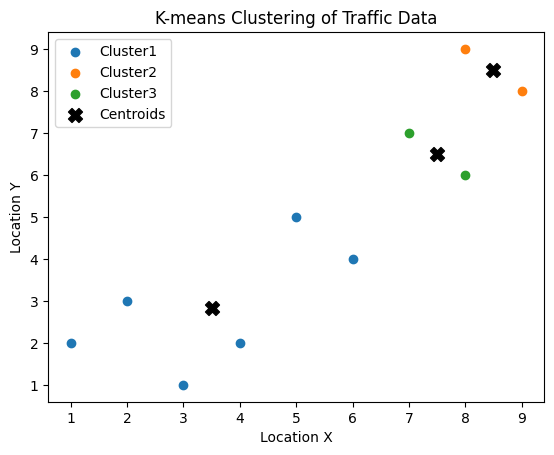

In [3]:
def visualize_traffic_clusters(X, idx, centroids):
    for k in range(K):
        cluster = X[idx == k]
        plt.scatter(cluster[:, 0], cluster[
                    :, 1], label=f"Cluster{k+1}")
    plt.scatter(centroids[:, 0], centroids[
                :, 1], color='black', marker='X', s=100, label="Centroids")
    plt.legend()
    plt.xlabel("Location X")
    plt.ylabel("Location Y")
    plt.title("K-means Clustering of Traffic Data")
    plt.show()

visualize_traffic_clusters(traffic_data, idx, centroids)

### 2. Part 2: <u>Anomaly Detection For Energy Grid Monitoring</u>

Task:  implement a Gaussian-based anomaly detection algorithm to identify these anomalies.

#### 2.1 Load Energy Data

In [4]:
# Load energy data
energy_data = pd.read_csv("../data/energy_data.csv")

X_train = energy_data[energy_data['Label'] == 0][[
    'EnergyConsumption', 'Time']].values
X_val = energy_data[['EnergyConsumption', 'Time']].values
y_val = energy_data["Label"].values

#### 2.2 Estimating Gaussian Parameters
Implement a function to estimate the parameters of the Gaussian Distribution

In [5]:
def estimate_gaussian(X):
    mu = np.mean(X, axis=0)
    var = np.var(X, axis=0)
    return mu, var

def multivariate_gaussian(X, mu, var):
    k = len(mu)
    term1 = 1 / (np.sqrt((2 * np.pi) ** k * np.prod(var)))
    term2 = np.exp(-0.5 * np.sum(((X - mu) ** 2) / var, axis=1))
    return term1 * term2

#### 2.3 Selecting the Threshold based on F1-Score
Implement a function to select the best threshold

In [9]:
def select_threshold(y_val, p_val):
    best_epsilon = 0
    best_f1 = 0

    step_size = (max(p_val) - min(p_val)) / 1000

    for epsilon in np.arange(min(p_val), max(p_val), step_size):
        predictions = p_val < epsilon

        tp = np.sum((predictions == 1) & (y_val == 1))
        fp = np.sum((predictions == 1) & (y_val == 0))
        fn = np.sum((predictions == 0) & (y_val == 1))

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0

        if (precision + recall) > 0:
            f1 = 2 * precision * recall / (precision + recall)
        else:
            f1 = 0

        if f1 > best_f1:
            best_f1 = f1
            best_epsilon = epsilon

    return best_epsilon, best_f1

#### 2.4 Application to the Energy Data to discover Anomalies

In [10]:
# Estimate Gaussian Parameters
mu, var = estimate_gaussian(X_train)

# Calculate probabilities
p_val = multivariate_gaussian(X_val, mu, var)

# Select the best threshold
epsilon, F1 = select_threshold(energy_data['Label'].values, p_val)

# Identify anomalies
anomalies = p_val < epsilon

print("Number of anomalies found:", np.sum(anomalies))

Number of anomalies found: 3


#### 2.5 Visualize Anomaly
Implement a function to visualize the anomalies within the energy grid monitoring data

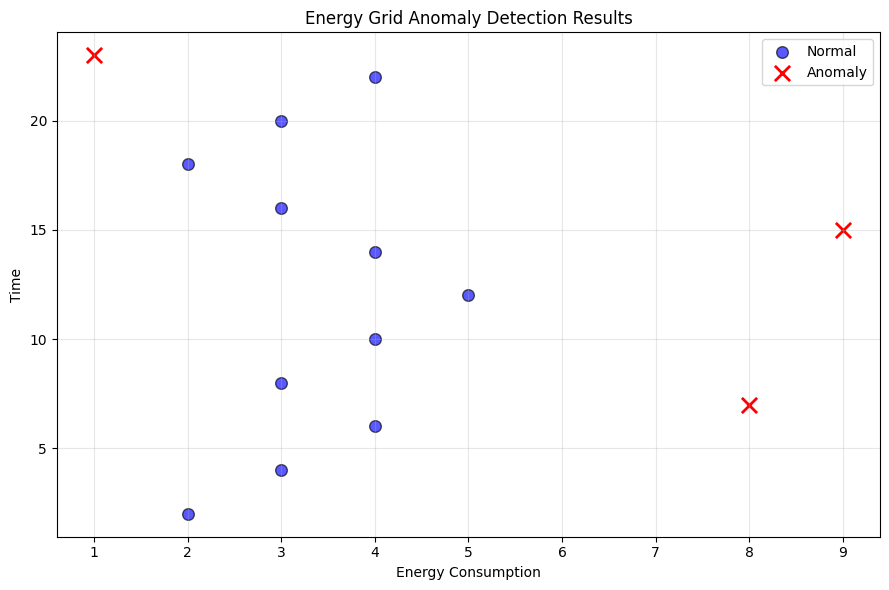

In [11]:
from pathlib import Path

def visualize_anomalies(X, anomalies_mask):
    plt.figure(figsize=(9, 6))

    plt.scatter(
        X[~anomalies_mask, 0],
        X[~anomalies_mask, 1],
        c="blue",
        label="Normal",
        alpha=0.65,
        s=70,
        edgecolor="black"
    )

    plt.scatter(
        X[anomalies_mask, 0],
        X[anomalies_mask, 1],
        c="red",
        label="Anomaly",
        marker="x",
        s=120,
        linewidths=2
    )

    plt.xlabel("Energy Consumption")
    plt.ylabel("Time")
    plt.title("Energy Grid Anomaly Detection Results")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    current_dir = Path.cwd()
    image_dir = current_dir.parent / "images" if current_dir.name == "notebooks" else current_dir / "images"
    image_dir.mkdir(exist_ok=True)

    plt.savefig(image_dir / "energy_grid_anomaly_detection.png", dpi=300, bbox_inches="tight")
    plt.show()

visualize_anomalies(X_val, anomalies)

### 3. <u>Clustering and Anomaly Detection Analysis</u>

In the first part of the smart city management implementation, a K-means clustering algorithm was applied to traffic data to understand spatial patterns in vehicle movement or congestion levels across different locations within the smart city. The clustering output, visualized with distinct color-coded clusters and bold black centroids, shows three well-defined groups of data points. Each cluster likely corresponds to zones with similar traffic density or flow characteristics — for instance, high-traffic zones, moderate areas, and low-density segments. The centroids represent the average location of activity within each group and can be interpreted as central hubs of traffic activity or control points for monitoring.

Complementing this, an anomaly detection model was applied to sensor data from Technopolis' energy grid to detect possible anomalies causing the inefficiencies in the energy grid. Using a multivariate Gaussian distribution, the system learned the normal behavior of the grid by analyzing the statistical patterns in historical readings. The resulting scatter plot clearly distinguished normal operating conditions from anomalies. Most data points clustered in a tight, central region of the plot representing stable, expected behavior. In contrast, the anomalies, marked with red Xs, were isolated and fell well outside the cluster, suggesting abnormal or potentially hazardous conditions such as equipment malfunctions, voltage spikes, or external disturbances. The model successfully identified these deviations by computing probability densities and applying a threshold optimized using the F1 score. This early detection of anomalies enhances the reliability and resilience of the energy grid, allowing operators to act proactively before faults escalate.